# WebCode2M — статистический анализ датасета

Ноутбук считает по датасету [`xcodemind/webcode2m_purified`](https://huggingface.co/datasets/xcodemind/webcode2m_purified)
метрики из `required_data.md`:

| # | Метрика | Как считается |
|---|---------|---------------|
| 1 | Количество примеров | точное `num_examples` из dataset info |
| 2 | Количество языков | нативное поле `lang` |
| 3 | Средний размер HTML | длина `text` в символах и байтах |
| 4 | Среднее количество DOM-узлов | lxml: элементы + текстовые узлы |
| 5 | Размер скриншота | разрешение в пикселях из поля `image` |
| 6 | Среднее количество CSS правил | все декларации `property: value` (инлайн + `<style>`) |
| 7 | Среднее количество выбранных источников | среднее число уникальных доменов на страницу |

Метрики 2–7 считаются по случайной выборке (`SAMPLE_SIZE`), метрика 1 — по всему
датасету. Тяжёлые объекты (изображения, HTML) в память не накапливаются: в цикле
берём только скалярные признаки.


## 1. Установка зависимостей

In [1]:
%pip install -q datasets lxml pandas matplotlib tqdm


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Импорты и конфигурация

In [2]:
import os
import re
import logging
from urllib.parse import urlparse

import pandas as pd
import matplotlib.pyplot as plt
from lxml import html as lxml_html
from tqdm.auto import tqdm

HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

import datasets
from datasets import load_dataset

logging.getLogger("httpx").setLevel(logging.WARNING)

DATASET = "xcodemind/webcode2m_purified"
SPLIT = "train"
SAMPLE_SIZE = 5000

print(f"datasets: {datasets.__version__}")
print(f"Датасет: {DATASET}, выборка: {SAMPLE_SIZE}")

# --- Токенная длина кода (метрика 3, на замену символьной) ---
from token_len import count_tokens, recommend_max_length
from transformers import AutoTokenizer
# Точный id — когда SFT зафиксирует модель. Счётчики токенов у Qwen 2.5/3/3.5
# практически совпадают, поэтому это валидный прокси для оценки бюджета max_length.
TOKENIZER_ID = "Qwen/Qwen3-VL-8B-Instruct"
IMAGE_TOKEN_BUDGET = 0   # бюджет визуальных токенов — заложить после согласования разрешения
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_ID)
print("tokenizer:", TOKENIZER_ID)


/Users/vyacheslav/Screenshot2Code/ScreenShot2Code/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


datasets: 5.0.0
Датасет: xcodemind/webcode2m_purified, выборка: 5000


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


tokenizer: Qwen/Qwen3-VL-8B-Instruct


## 3. Метрика 1 — количество примеров

Значение получено суммированием `num_rows` из footer'ов всех 2063 parquet-шардов
сплита `train`. Пересчитывать при каждом запуске дорого, поэтому фиксируем
константой.

In [3]:
TOTAL_EXAMPLES = 2_562_069
print(f"[Метрика 1] Количество примеров в датасете ({SPLIT}): {TOTAL_EXAMPLES:,}")

[Метрика 1] Количество примеров в датасете (train): 2,562,069


## 4. Загрузка стрим-датасета

In [4]:
dataset = load_dataset(DATASET, streaming=True)
dataset

IterableDatasetDict({
    train: IterableDataset({
        features: ['image', 'bbox', 'text', 'score', 'scale', 'lang', 'tokens', 'hash'],
        num_shards: 2063
    })
})

## 5. Функции-хелперы

Все метрики извлекаются из одного распарсенного DOM-дерева, чтобы парсить HTML
лишь один раз на пример.

In [5]:
def count_dom_nodes(tree):
    # //text() включает whitespace-узлы (переносы строк между тегами) — фильтруем пустые,
    # иначе DOM-count завышается форматированием кода.
    return len(tree.xpath(".//*")) + len(tree.xpath("//text()[normalize-space()]"))


# Декларация property:value. Исключаем ложные срабатывания на url(http://...) и data:
# (лишние двоеточия в значениях) — берём первое двоеточие как разделитель property/value.
_DECL_RE = re.compile(r"[A-Za-z-]+\s*:[^;{}]+")

def _count_declarations(css_body):
    return sum(1 for _ in _DECL_RE.finditer(css_body))

def count_css_declarations(tree):
    total = 0
    for style_attr in tree.xpath("//*/@style"):
        total += _count_declarations(style_attr)
    for style_text in tree.xpath("//style//text()"):
        for block in re.findall(r"\{([^{}]*)\}", style_text):
            total += _count_declarations(block)
    return total


def count_unique_domains(tree):
    domains = set()
    for url in tree.xpath("//@src | //@href | //@data-src"):
        url = (url or "").strip()
        if not url or url.startswith(("#", "mailto:", "tel:", "javascript:", "data:")):
            continue
        parse_target = "http:" + url if url.startswith("//") else url
        netloc = urlparse(parse_target).netloc.lower()
        if netloc:
            domains.add(netloc)
    return len(domains)

## 6. Главный цикл по выборке

Итерируемся по `SAMPLE_SIZE` примерам, парсим HTML один раз и собираем только
скалярные признаки. Изображения и HTML в память не сохраняются.

In [6]:
records = []

for row in tqdm(dataset[SPLIT].take(SAMPLE_SIZE), total=SAMPLE_SIZE, desc="Обработка"):
    text = row.get("text") or ""
    img = row.get("image")
    img_w, img_h = (img.size if img is not None else (None, None))

    lang = row.get("lang")
    lang = str(lang).strip().lower() if lang else "unknown"

    rec = {
        "html_chars": len(text),
        "html_tokens": count_tokens(text, tokenizer),
        "html_bytes": len(text.encode("utf-8")),
        "img_w": img_w,
        "img_h": img_h,
        "dom_nodes": None,
        "css_decls": None,
        "n_domains": None,
        "lang": lang,
        "parse_ok": False,
    }
    try:
        tree = lxml_html.fromstring(text)
        rec["dom_nodes"] = count_dom_nodes(tree)
        rec["css_decls"] = count_css_declarations(tree)
        rec["n_domains"] = count_unique_domains(tree)
        rec["parse_ok"] = True
    except Exception:
        pass

    records.append(rec)

print(f"Собрано записей: {len(records)}, распарсено успешно: {sum(r['parse_ok'] for r in records)}")

Обработка: 100%|██████████| 5000/5000 [02:30<00:00, 33.31it/s]

Собрано записей: 5000, распарсено успешно: 5000


## 7. DataFrame с признаками

In [7]:
df = pd.DataFrame(records)
print(f"Размер списка признаков в памяти: {df.memory_usage(deep=True).sum() / 1024**2:.2f} МБ")
df.head()

Размер списка признаков в памяти: 0.36 МБ


,html_chars,html_tokens,html_bytes,img_w,img_h,dom_nodes,css_decls,n_domains,lang,parse_ok
0,6696,2371,6696,1280,1246,227,75,0,en,True
1,9400,3362,10637,1280,2138,337,11,0,ja,True
2,17869,5544,17869,1280,1207,162,267,1,en,True
3,8331,2609,8364,1280,1262,255,35,1,en,True
4,8492,2641,8539,1280,2518,224,30,2,en,True


## 8. Агрегированные метрики

Считаем только по успешно распарсенным примерам.

In [8]:
ok = df[df["parse_ok"]]

agg = pd.DataFrame({
    "mean":   [ok["html_chars"].mean(), ok["html_bytes"].mean(), ok["dom_nodes"].mean(),
               ok["css_decls"].mean(), ok["n_domains"].mean(), ok["img_h"].mean()],
    "median": [ok["html_chars"].median(), ok["html_bytes"].median(), ok["dom_nodes"].median(),
               ok["css_decls"].median(), ok["n_domains"].median(), ok["img_h"].median()],
    "std":    [ok["html_chars"].std(), ok["html_bytes"].std(), ok["dom_nodes"].std(),
               ok["css_decls"].std(), ok["n_domains"].std(), ok["img_h"].std()],
    "min":    [ok["html_chars"].min(), ok["html_bytes"].min(), ok["dom_nodes"].min(),
               ok["css_decls"].min(), ok["n_domains"].min(), ok["img_h"].min()],
    "max":    [ok["html_chars"].max(), ok["html_bytes"].max(), ok["dom_nodes"].max(),
               ok["css_decls"].max(), ok["n_domains"].max(), ok["img_h"].max()],
}, index=["HTML символов", "HTML байт", "DOM-узлы", "CSS декларации",
          "Уникальные домены", "Высота скриншота, px"])

agg.round(1)

,mean,median,std,min,max
HTML символов,13992.3,12943.0,5934.2,1453,32377
HTML байт,14239.5,13127.0,5949.0,1453,36144
DOM-узлы,254.1,242.0,119.6,20,1387
CSS декларации,173.0,137.0,135.8,4,798
Уникальные домены,1.1,1.0,1.0,0,9
"Высота скриншота, px",1624.2,1604.0,514.2,720,3815


### 8b. Среднее vs медиана — проверка на скошенность

По гистограммам похоже, что размеры (HTML/DOM/CSS) сильно скошены вправо:
небольшое число очень крупных страниц тянет среднее заметно выше медианы.
Ниже — прямое сравнение `mean` и `median` по всем размерным метрикам плюс
коэффициент скошенности `mean / median` (чем сильнее он выше 1, тем длиннее
правый хвост распределения) и `p90`/`p99` для масштаба хвоста.

In [9]:
_skew_cols = {
    "Код (токены)": "html_tokens",
    "HTML символов": "html_chars",
    "HTML байт": "html_bytes",
    "DOM-узлы": "dom_nodes",
    "CSS декларации": "css_decls",
    "Уникальные домены": "n_domains",
    "Высота скриншота, px": "img_h",
}

skew = pd.DataFrame({
    "median": [ok[c].median() for c in _skew_cols.values()],
    "mean":   [ok[c].mean() for c in _skew_cols.values()],
    "p90":    [ok[c].quantile(0.90) for c in _skew_cols.values()],
    "p99":    [ok[c].quantile(0.99) for c in _skew_cols.values()],
    "max":    [ok[c].max() for c in _skew_cols.values()],
}, index=list(_skew_cols.keys()))

skew["mean / median"] = (skew["mean"] / skew["median"]).round(2)
skew = skew[["median", "mean", "mean / median", "p90", "p99", "max"]]
skew.round(1)

,median,mean,mean / median,p90,p99,max
Код (токены),4133.0,4559.5,1.1,7397.6,9919.1,12921
HTML символов,12943.0,13992.3,1.1,22729.8,29572.1,32377
HTML байт,13127.0,14239.5,1.1,23040.6,29738.1,36144
DOM-узлы,242.0,254.1,1.0,389.0,616.0,1387
CSS декларации,137.0,173.0,1.3,363.0,610.0,798
Уникальные домены,1.0,1.1,1.1,2.0,5.0,9
"Высота скриншота, px",1604.0,1624.2,1.0,2322.4,2560.0,3815


## 9. Метрика 2 — количество языков

Источник — нативное поле `lang` (языковая разметка авторов датасета: именно на
этих языках учится модель).

In [10]:
lang_counts = df["lang"].value_counts()
n_langs = df.loc[df["lang"] != "unknown", "lang"].nunique()

print(f"[Метрика 2] Уникальных языков (поле lang): {n_langs}")
print("\nТоп-15 языков:")
lang_counts.head(15)

[Метрика 2] Уникальных языков (поле lang): 19

Топ-15 языков:


lang
en    2597
es     342
de     338
zh     230
fr     215
nl     190
ja     188
hi     130
tr     128
bg     109
it     106
ur      99
vi      86
pl      82
pt      73
Name: count, dtype: int64

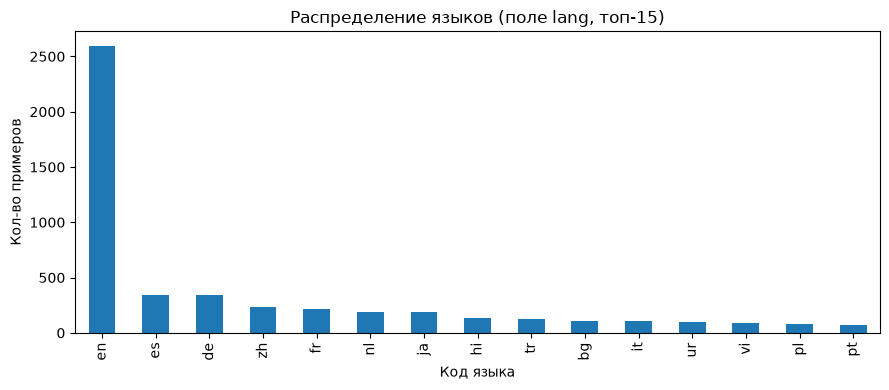

In [11]:
top_langs = lang_counts.head(15)
plt.figure(figsize=(9, 4))
top_langs.plot(kind="bar")
plt.title("Распределение языков (поле lang, топ-15)")
plt.ylabel("Кол-во примеров")
plt.xlabel("Код языка")
plt.tight_layout()
plt.show()

## 10. Гистограммы распределений

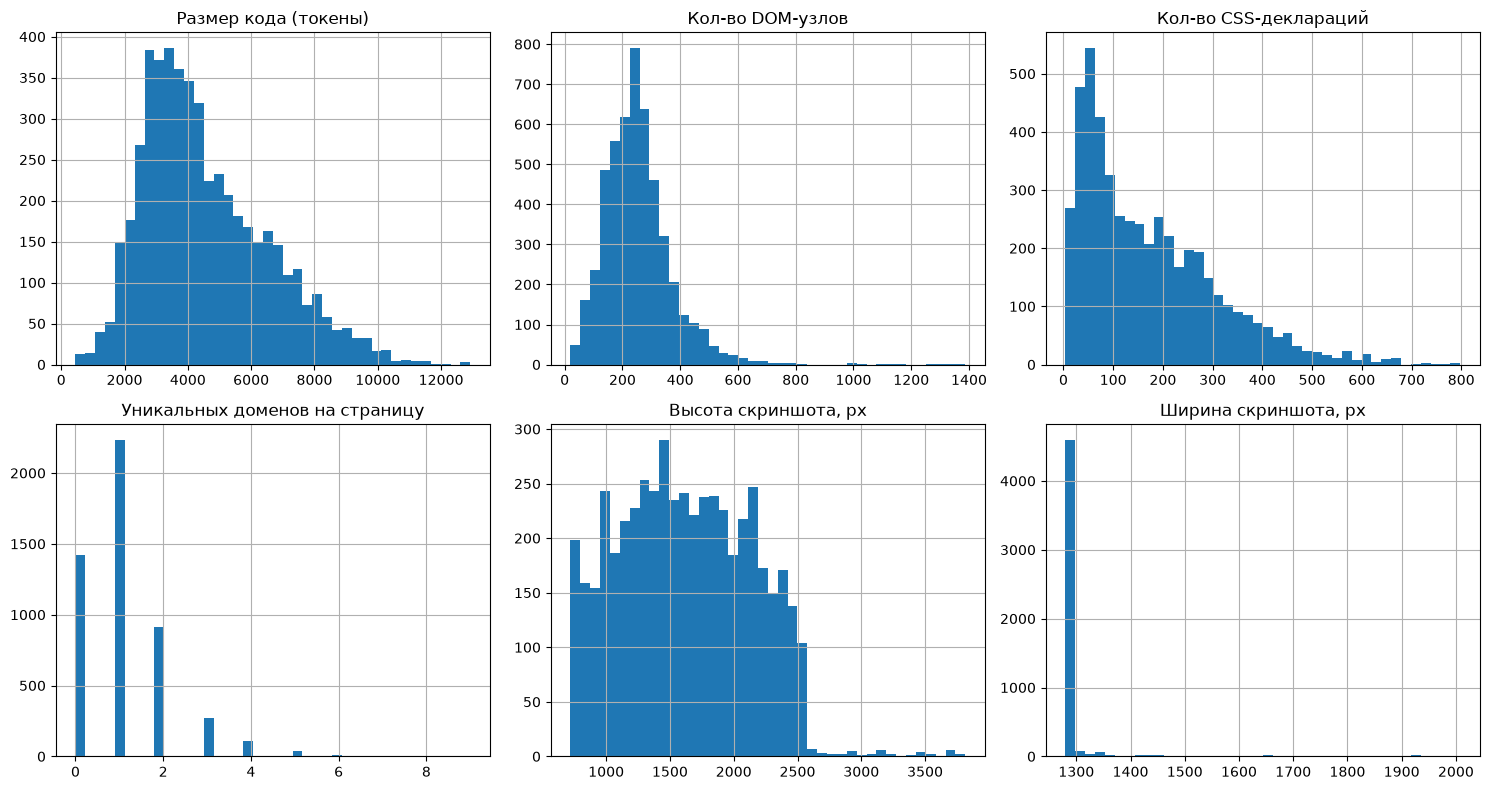

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

ok["html_tokens"].hist(ax=axes[0, 0], bins=40)
axes[0, 0].set_title("Размер кода (токены)")

ok["dom_nodes"].hist(ax=axes[0, 1], bins=40)
axes[0, 1].set_title("Кол-во DOM-узлов")

ok["css_decls"].hist(ax=axes[0, 2], bins=40)
axes[0, 2].set_title("Кол-во CSS-деклараций")

ok["n_domains"].hist(ax=axes[1, 0], bins=40)
axes[1, 0].set_title("Уникальных доменов на страницу")

ok["img_h"].hist(ax=axes[1, 1], bins=40)
axes[1, 1].set_title("Высота скриншота, px")

ok["img_w"].hist(ax=axes[1, 2], bins=40)
axes[1, 2].set_title("Ширина скриншота, px")

plt.tight_layout()
plt.show()

## 11. Итоговая сводка

Сопоставление с каждым пунктом `required_data.md`.

In [13]:
def fmt(x):
    return f"{x:,.1f}" if x is not None else "n/a"

w_mode = ok["img_w"].mode()
w_mode = int(w_mode.iloc[0]) if len(w_mode) else None

summary = pd.DataFrame([
    ("1. Количество примеров",                 f"{TOTAL_EXAMPLES:,}" if TOTAL_EXAMPLES else "n/a"),
    ("2. Количество языков",                   f"{n_langs}"),
    ("3. Средний размер кода (токены, Qwen)",  fmt(ok["html_tokens"].mean())),
    ("   p99 токенов (ориентир для max_length)", fmt(ok["html_tokens"].quantile(0.99))),
    ("   размер HTML (символы, справочно)",    fmt(ok["html_chars"].mean())),
    ("   Средний размер HTML (байт)",          fmt(ok["html_bytes"].mean())),
    ("4. Среднее кол-во DOM-узлов",            fmt(ok["dom_nodes"].mean())),
    ("5. Размер скриншота (W x H, px)",        f"{w_mode} x {fmt(ok['img_h'].mean())} (средняя высота)"),
    ("6. Среднее кол-во CSS правил",           fmt(ok["css_decls"].mean())),
    ("7. Среднее кол-во уникальных доменов",   fmt(ok["n_domains"].mean())),
], columns=["Метрика (required_data.md)", "Значение"])

print(f"Выборка для метрик 2-7: {len(ok):,} успешно распарсенных примеров "
      f"(из {len(df):,} загруженных)\n")
summary

Выборка для метрик 2-7: 5,000 успешно распарсенных примеров (из 5,000 загруженных)



,Метрика (required_data.md),Значение
0,1. Количество примеров,"2,562,069"
1,2. Количество языков,19
2,"3. Средний размер кода (токены, Qwen)","4,559.5"
3,p99 токенов (ориентир для max_length),"9,919.1"
4,"размер HTML (символы, справочно)","13,992.3"
5,Средний размер HTML (байт),"14,239.5"
6,4. Среднее кол-во DOM-узлов,254.1
7,"5. Размер скриншота (W x H, px)","1280 x 1,624.2 (средняя высота)"
8,6. Среднее кол-во CSS правил,173.0
9,7. Среднее кол-во уникальных доменов,1.1


## Рекомендуемый max_length (токены)

In [14]:
# Ориентир max_length (контракт SFT): p99 длины кода в токенах, округл. вверх до 64,
# + бюджет визуальных токенов. Та же логика, что compute_max_length в token_len.py.
_tok_col = "code_tokens" if "code_tokens" in ok.columns else "html_tokens"
_rec = recommend_max_length(ok[_tok_col].tolist(), quantile=0.99, round_to=64,
                            image_token_budget=IMAGE_TOKEN_BUDGET)
print(f"Токены кода: median={ok[_tok_col].median():.0f}, "
      f"p99={ok[_tok_col].quantile(0.99):.0f}, max={ok[_tok_col].max():.0f}")
print(f"Рекомендуемый max_length (p99 → округл. 64, +img {IMAGE_TOKEN_BUDGET}): {_rec}")

Токены кода: median=4133, p99=9919, max=12921
Рекомендуемый max_length (p99 → округл. 64, +img 0): 9920


## 12. Все графики вместе

Те же графики из разделов 9–10, собранные в одну сетку — для скриншота.

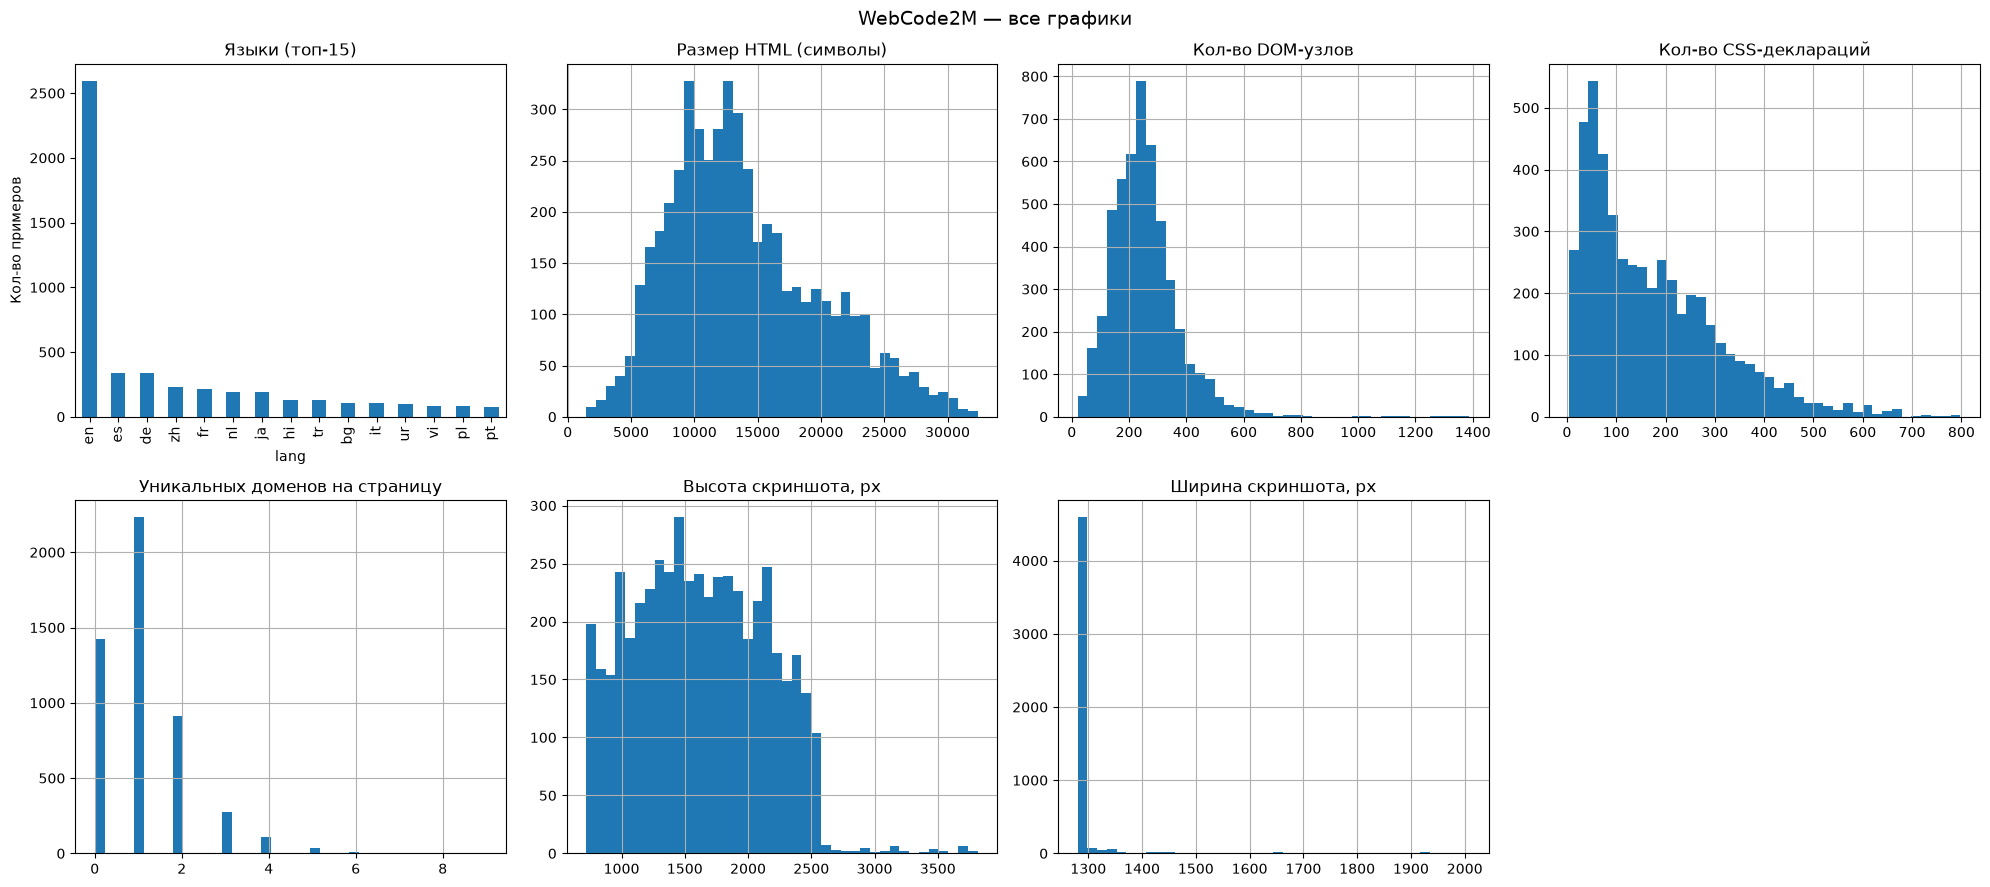

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

top_langs.plot(kind="bar", ax=axes[0])
axes[0].set_title("Языки (топ-15)")
axes[0].set_ylabel("Кол-во примеров")

ok["html_chars"].hist(ax=axes[1], bins=40)
axes[1].set_title("Размер HTML (символы)")

ok["dom_nodes"].hist(ax=axes[2], bins=40)
axes[2].set_title("Кол-во DOM-узлов")

ok["css_decls"].hist(ax=axes[3], bins=40)
axes[3].set_title("Кол-во CSS-деклараций")

ok["n_domains"].hist(ax=axes[4], bins=40)
axes[4].set_title("Уникальных доменов на страницу")

ok["img_h"].hist(ax=axes[5], bins=40)
axes[5].set_title("Высота скриншота, px")

ok["img_w"].hist(ax=axes[6], bins=40)
axes[6].set_title("Ширина скриншота, px")

axes[7].axis("off")

fig.suptitle("WebCode2M — все графики", fontsize=14)
plt.tight_layout()
plt.show()